Data berhasil dimuat!
Epoch 10/50 - Loss: 0.5490
Epoch 20/50 - Loss: 0.4785
Epoch 30/50 - Loss: 0.4508
Epoch 40/50 - Loss: 0.4323
Epoch 50/50 - Loss: 0.4239


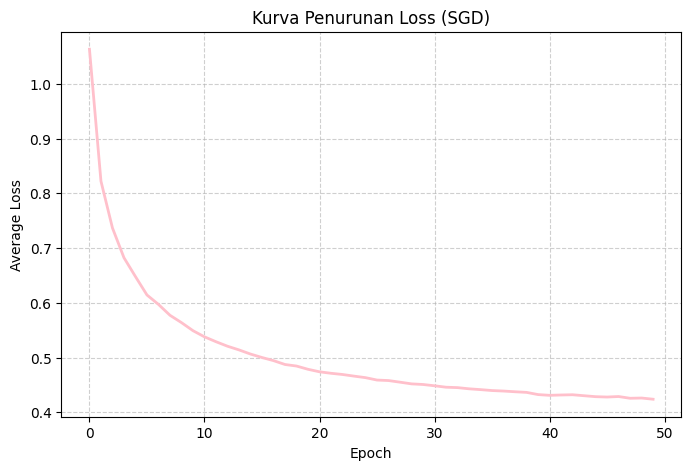


Akurasi Model: 81.80%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('train.csv')
    print("Data berhasil dimuat!")
except:
    print("File train.csv tidak ditemukan. Pastikan sudah di-upload ke Colab.")

X = df[['ram', 'battery_power']].values
y = df['price_range'].values

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)

V = 4
D = 2
W = np.random.randn(V, D) * 0.01
b = np.zeros(V)
lr = 0.05
epochs = 50

def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / exp_z.sum()

losses = []
for epoch in range(epochs):
    epoch_loss = 0
    indices = np.arange(len(X_scaled))
    np.random.shuffle(indices)

    for i in indices:
        xi = X_scaled[i]
        yi = y[i]

        z = np.dot(W, xi) + b
        probs = softmax(z)

        epoch_loss -= np.log(probs[yi] + 1e-9)

        eps = probs.copy()
        eps[yi] -= 1

        for c in range(V):
            W[c] -= lr * eps[c] * xi
            b[c] -= lr * eps[c]

    losses.append(epoch_loss / len(X_scaled))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {losses[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(losses, color='pink', linewidth=2)
plt.title('Kurva Penurunan Loss (SGD)')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

correct = 0
for i in range(len(X_scaled)):
    z = np.dot(W, X_scaled[i]) + b
    if np.argmax(z) == y[i]:
        correct += 1
print(f"\nAkurasi Model: {correct/len(X_scaled) * 100:.2f}%")